In [13]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict
from dotenv import load_dotenv
import os
from langchain_mistralai import ChatMistralAI

In [43]:
import os
from dotenv import load_dotenv
from langchain_mistralai import ChatMistralAI

# 1. Force reload the environment variables from your .env file
load_dotenv()

# 2. Get your key using your specific key name
api_key = os.getenv("mistral_APIKEY")

# 3. Explicitly pass it using the 'mistral_api_key' argument
model = ChatMistralAI(
    model="mistral-large-latest",
    temperature=0.7,
    mistral_api_key=api_key  # <-- Crucial fix!
)

In [64]:
class BlogState(TypedDict):
    topic:str
    title:str
    outline:str
    blog:str
    evaluate:int
    feedback:list[str]

In [70]:
graph = StateGraph(BlogState)
#node
graph.add_node("create_outline", create_outline)
#node
graph.add_node("create_blog", create_blog)
graph.add_node("evaluate", evaluate)
#edges
graph.add_edge(START, "create_outline")
graph.add_edge("create_outline", "create_blog")
graph.add_edge("create_blog" , "evaluate")
graph.add_edge("evaluate", END)
#compile
workflow = graph.compile()

In [66]:
def create_outline(state:BlogState)->BlogState:
    title = state['title']
    prompt = f"Create a detailed outline for a blog post with the title: {title}"
    response = model.invoke(prompt).content
    state['outline'] = response
    return state

In [67]:
def create_blog(state:BlogState)->BlogState:
    outline = state["outline"]
    title = state["title"]
    prompt = f"write a blog post based title - {title} using the following outline: {outline}\n\n blog post:"
    response = model.invoke(prompt).content
    state['blog'] = response
    return state
    

In [76]:
initial_state = BlogState(topic="AI" , title="the future of Ai" , outline="" , evaluate=0 , feedback=[])
final_state=workflow.invoke(initial_state)
print(final_state)

{'topic': 'AI', 'title': 'the future of Ai', 'outline': '# **Blog Post Outline: The Future of AI**\n\n## **Title:**\n**The Future of AI: Trends, Challenges, and What Lies Ahead**\n\n## **Introduction**\n- **Hook:** Start with a thought-provoking question or statistic about AI’s rapid growth.\n  - *Example:* *"By 2030, AI could contribute up to $15.7 trillion to the global economy—more than the current output of China and India combined. But what does the future of AI really look like?"*\n- **Brief Overview:** Define AI and its current impact on industries, society, and daily life.\n- **Purpose of the Post:** Explain why understanding AI’s future is crucial for businesses, policymakers, and individuals.\n- **Thesis Statement:** AI will continue to evolve, transforming industries, ethics, and human-machine interactions in unprecedented ways.\n\n---\n\n## **1. The Evolution of AI: A Brief History**\n*(Provide context for readers unfamiliar with AI’s development.)*\n- **Early AI (1950s–198

In [75]:
def evaluate(state:BlogState)->BlogState:
    evaluate = state['evaluate']
    blog = state['blog']
    prompt = f"Evaluate the quality of the following blog post and provide feedback for improvement:\n\n{blog}\n\nFeedback:"
    response = model.invoke(prompt).content
    state["feedback"] = response 
    state["evaluate"] = evaluate + 1
    return state

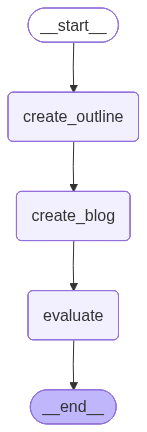

In [74]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())

In [73]:
print(final_state['feedback'])

This is an **exceptionally well-researched, comprehensive, and engaging** blog post that effectively covers the future of AI from multiple angles—technical, ethical, economic, and societal. Below is a detailed evaluation of its strengths and areas for improvement, along with actionable feedback.

---

## **Strengths of the Blog Post**

### **1. Structure & Organization**
✅ **Clear, Logical Flow**
- The post follows a **well-defined structure** (Introduction → Evolution → Trends → Challenges → Human-AI Relationship → Actionable Steps → Conclusion).
- Each section builds on the previous one, making it easy to follow.
- **Table of contents** (implied via section headers) helps readers navigate.

✅ **Strong Introduction & Conclusion**
- The **hook** (PwC’s $15.7 trillion statistic) is compelling.
- The **thesis statement** clearly outlines what the post will cover.
- The **conclusion** effectively summarizes key takeaways and ends with an **engaging question** to prompt discussion.

✅ **Vi